# Wildfire Detection — Progress Report
**CS464 Machine Learning, Group 20**

Binary classification of wildfire vs. non-wildfire images using EfficientNet-B0.

## Cell 1: Environment & GPU Check

In [ ]:
import torch
print(f"GPU available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

## Cell 2: Dataset Download

In [3]:
# ============================================================
# Option A: Kaggle API (uncomment this block to use)
# ============================================================
!pip install -q kaggle
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d elmadafri/the-wildfire-dataset -p /content/data --unzip

# ============================================================
# Option B: Dataset already on Google Drive (uncomment this block to use)
# ============================================================
# !unzip /content/drive/MyDrive/wildfire-dataset.zip -d /content/data

cp: cannot stat '/content/drive/MyDrive/kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/elmadafri/the-wildfire-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 9.94G/9.94G [11:25<00:00, 15.6MB/s]



In [6]:
import os

DATA_ROOT = '/content/data/the_wildfire_dataset_2n_version'

# Print folder structure
for root, dirs, files in os.walk(DATA_ROOT):
    level = root.replace(DATA_ROOT, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        for d in dirs:
            print(f'{indent}  {d}/')

# Count total files
total = sum(len(files) for _, _, files in os.walk(DATA_ROOT))
print(f'\nTotal files: {total}')

the_wildfire_dataset_2n_version/
  test/
  train/
  val/
  test/
    nofire/
    fire/
    nofire/
    fire/
  train/
    nofire/
    fire/
    nofire/
    fire/
  val/
    nofire/
    fire/
    nofire/
    fire/

Total files: 2700


In [5]:
# Check the contents of the unzipped data directory
!ls -l /content/data

total 4
drwxr-xr-x 5 root root 4096 Apr  4 22:32 the_wildfire_dataset_2n_version


## Cell 3: Mount Google Drive (for saving outputs)

In [7]:
from google.colab import drive
drive.mount('/content/drive')

OUTPUT_DIR = '/content/drive/MyDrive/CS464_Wildfire/outputs'
CHECKPOINT_DIR = '/content/drive/MyDrive/CS464_Wildfire/checkpoints'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print(f'Output dir:     {OUTPUT_DIR}')
print(f'Checkpoint dir: {CHECKPOINT_DIR}')

Mounted at /content/drive
Output dir:     /content/drive/MyDrive/CS464_Wildfire/outputs
Checkpoint dir: /content/drive/MyDrive/CS464_Wildfire/checkpoints


## Cell Group 4: Dataset Exploration

In [8]:
import random
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

random.seed(42)

# Collect all image paths and labels
train_dir = os.path.join(DATA_ROOT, 'train')
class_names = sorted(os.listdir(train_dir))  # e.g. ['nofire', 'wildfire']
print(f'Classes found: {class_names}')

# Gather images from train + val + test folders
all_image_paths = []
class_counts = {}

for split in ['train', 'val', 'test']:
    split_dir = os.path.join(DATA_ROOT, split)
    if not os.path.isdir(split_dir):
        continue
    for cls in class_names:
        cls_dir = os.path.join(split_dir, cls)
        if not os.path.isdir(cls_dir):
            continue
        imgs = [os.path.join(cls_dir, f) for f in os.listdir(cls_dir)
                if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp'))]
        all_image_paths.extend([(p, cls) for p in imgs])
        class_counts[cls] = class_counts.get(cls, 0) + len(imgs)

print(f'\nTotal images: {len(all_image_paths)}')
for cls, count in class_counts.items():
    print(f'  {cls}: {count}')

# Class balance ratio
counts = list(class_counts.values())
print(f'\nClass balance ratio: {min(counts)/max(counts):.3f}')

# Resolution statistics (sample ~500 images)
sample_paths = random.sample(all_image_paths, min(500, len(all_image_paths)))
widths, heights = [], []
for path, _ in sample_paths:
    try:
        with Image.open(path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
    except Exception:
        continue

print(f'\nResolution statistics (sampled {len(widths)} images):')
print(f'  Width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}')
print(f'  Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}')

Classes found: ['fire', 'nofire']

Total images: 2699
  fire: 1045
  nofire: 1654

Class balance ratio: 0.632

Resolution statistics (sampled 500 images):
  Width  — min: 180, max: 14535, mean: 4127
  Height — min: 240, max: 8319, mean: 3150


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (89747104 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


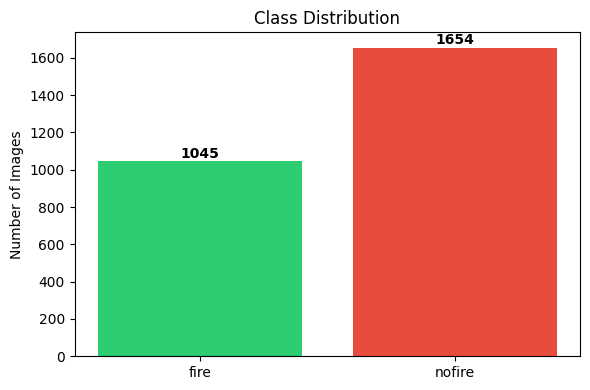

Saved to /content/drive/MyDrive/CS464_Wildfire/outputs/class_distribution.png


In [9]:
# Class distribution bar chart
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(class_counts.keys(), class_counts.values(), color=['#2ecc71', '#e74c3c'])
ax.set_title('Class Distribution')
ax.set_ylabel('Number of Images')
for bar, count in zip(bars, class_counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(count), ha='center', fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'class_distribution.png'), dpi=150)
plt.show()
print(f'Saved to {OUTPUT_DIR}/class_distribution.png')

## Cell Group 5: Preprocessing & DataLoaders

In [12]:
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms

torch.manual_seed(42)
np.random.seed(42)

# Remove corrupted images
valid_paths = []
corrupted = 0
for path, label in all_image_paths:
    try:
        with Image.open(path) as img:
            img.verify()
        valid_paths.append((path, label))
    except Exception:
        corrupted += 1

print(f'Valid images: {len(valid_paths)}, Corrupted/removed: {corrupted}')

# Encode labels
label_to_idx = {cls: i for i, cls in enumerate(class_names)}
paths = [p for p, _ in valid_paths]
labels = [label_to_idx[l] for _, l in valid_paths]

# Stratified 70/15/15 split
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    paths, labels, test_size=0.30, stratify=labels, random_state=42
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.50, stratify=temp_labels, random_state=42
)

print(f'Train: {len(train_paths)}, Val: {len(val_paths)}, Test: {len(test_paths)}')

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (104688771 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (89747104 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Valid images: 2699, Corrupted/removed: 0
Train: 1889, Val: 405, Test: 405


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (96631920 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (101859328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (94487082 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


In [13]:
# Transforms
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class WildfireDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

train_dataset = WildfireDataset(train_paths, train_labels, train_transform)
val_dataset = WildfireDataset(val_paths, val_labels, val_test_transform)
test_dataset = WildfireDataset(test_paths, test_labels, val_test_transform)

# WeightedRandomSampler for class imbalance
train_label_counts = np.bincount(train_labels)
class_weights = 1.0 / train_label_counts
sample_weights = [class_weights[l] for l in train_labels]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler,
                          num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False,
                        num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False,
                         num_workers=2, pin_memory=True)

print('DataLoaders ready.')

DataLoaders ready.


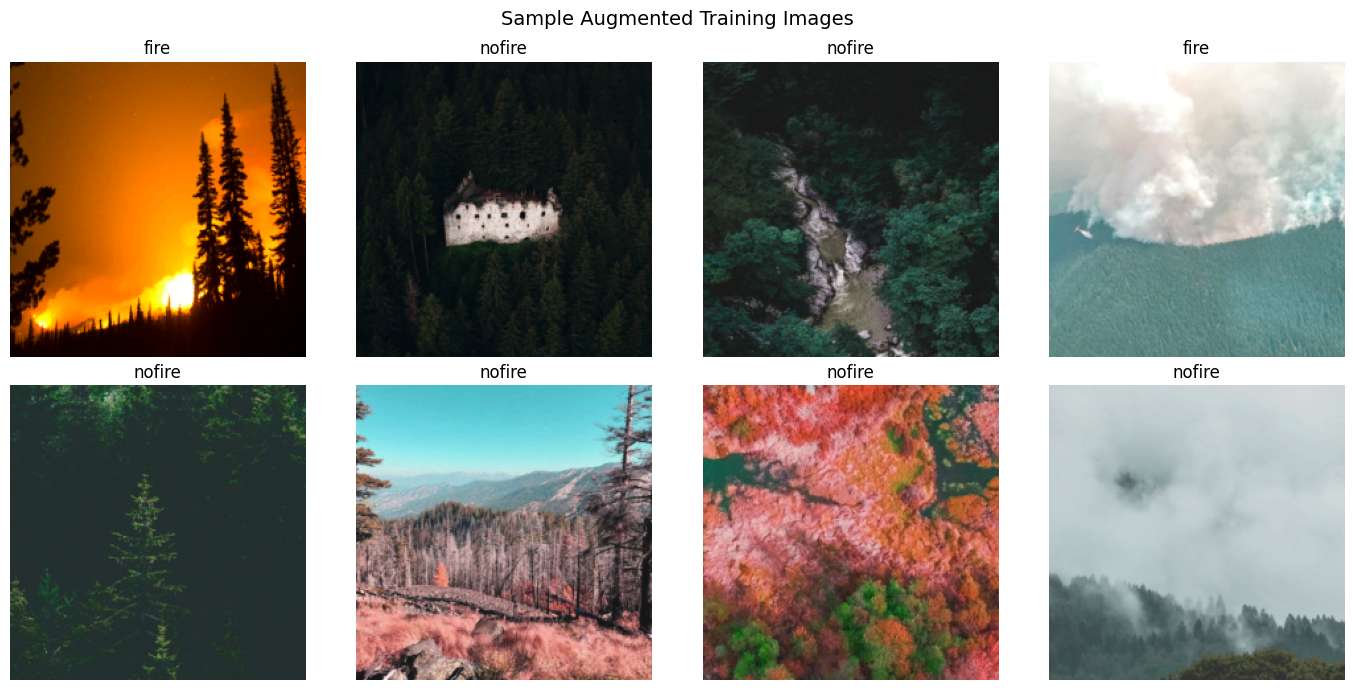

In [14]:
# Display 8 sample augmented training images
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    img = inv_normalize(img).clamp(0, 1)
    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.set_title(class_names[label])
    ax.axis('off')
plt.suptitle('Sample Augmented Training Images', fontsize=14)
plt.tight_layout()
plt.show()

## Cell Group 6: Model Definition — EfficientNet-B0

In [15]:
from torchvision import models
import torch.nn as nn

model = models.efficientnet_b0(weights='IMAGENET1K_V1')
model.classifier[1] = nn.Linear(1280, 2)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 220MB/s]


Total parameters:     4,010,110
Trainable parameters: 4,010,110


## Cell Group 7: Training Loop

In [16]:
from sklearn.metrics import f1_score
from tqdm.auto import tqdm

torch.manual_seed(42)

# Class weights for loss
cw = torch.tensor(class_weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=cw)

scaler = torch.amp.GradScaler('cuda')

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
best_val_f1 = 0.0

def train_one_epoch(model, loader, optimizer):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(loader, desc='  Train', leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            outputs = model(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += images.size(0)
    return running_loss / total, correct / total

def validate(model, loader):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc='  Val', leave=False):
            images, labels = images.to(device), labels.to(device)
            with torch.amp.autocast('cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += images.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    f1 = f1_score(all_labels, all_preds, average='binary', pos_label=1)
    return running_loss / total, correct / total, f1

print('Training functions defined.')

Training functions defined.


In [17]:
# ==============================
# Phase 1: Frozen backbone (5 epochs)
# ==============================
print('Phase 1: Training classifier head (backbone frozen)')
print('=' * 60)

# Freeze all layers except classifier
for param in model.parameters():
    param.requires_grad = False
for param in model.classifier.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(model.classifier.parameters(), lr=1e-3)

for epoch in range(1, 6):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer)
    val_loss, val_acc, val_f1 = validate(model, val_loader)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f'Epoch {epoch}/5 | '
          f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} F1: {val_f1:.4f}')

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, 'best_efficientnet.pth'))
        print(f'  -> Best model saved (F1={val_f1:.4f})')

print(f'\nPhase 1 complete. Best Val F1: {best_val_f1:.4f}')

Phase 1: Training classifier head (backbone frozen)


  Train:   0%|          | 0/60 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (101859328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (96631920 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (94487082 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (104688771 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


  Val:   0%|          | 0/13 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (89747104 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


...

  Train:   0%|          | 0/60 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (94487082 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (94487082 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79dde3f24cc0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^

  Val:   0%|          | 0/13 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (89747104 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Epoch 5/5 | Train Loss: 0.3950 Acc: 0.7999 | Val Loss: 0.3152 Acc: 0.8667 F1: 0.8836

Phase 1 complete. Best Val F1: 0.8884


In [18]:
# ==============================
# Phase 2: Full fine-tuning (10 epochs)
# ==============================
torch.cuda.empty_cache()

print('\nPhase 2: Full fine-tuning')
print('=' * 60)

# Unfreeze all layers
for param in model.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

for epoch in range(1, 11):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer)
    val_loss, val_acc, val_f1 = validate(model, val_loader)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f'Epoch {epoch}/10 | '
          f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} F1: {val_f1:.4f}')

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, 'best_efficientnet.pth'))
        print(f'  -> Best model saved (F1={val_f1:.4f})')

print(f'\nPhase 2 complete. Best Val F1: {best_val_f1:.4f}')


Phase 2: Full fine-tuning


  Train:   0%|          | 0/60 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (94487082 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79dde3f24cc0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79dde3f24cc0>
Traceback (most recent call last):
  File "/usr/lo

  Val:   0%|          | 0/13 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (89747104 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


...

  Train:   0%|          | 0/60 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (104688771 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (104688771 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (96631920 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


  Val:   0%|          | 0/13 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (89747104 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Epoch 10/10 | Train Loss: 0.1339 Acc: 0.9365 | Val Loss: 0.1207 Acc: 0.9704 F1: 0.9760
  -> Best model saved (F1=0.9760)

Phase 2 complete. Best Val F1: 0.9760


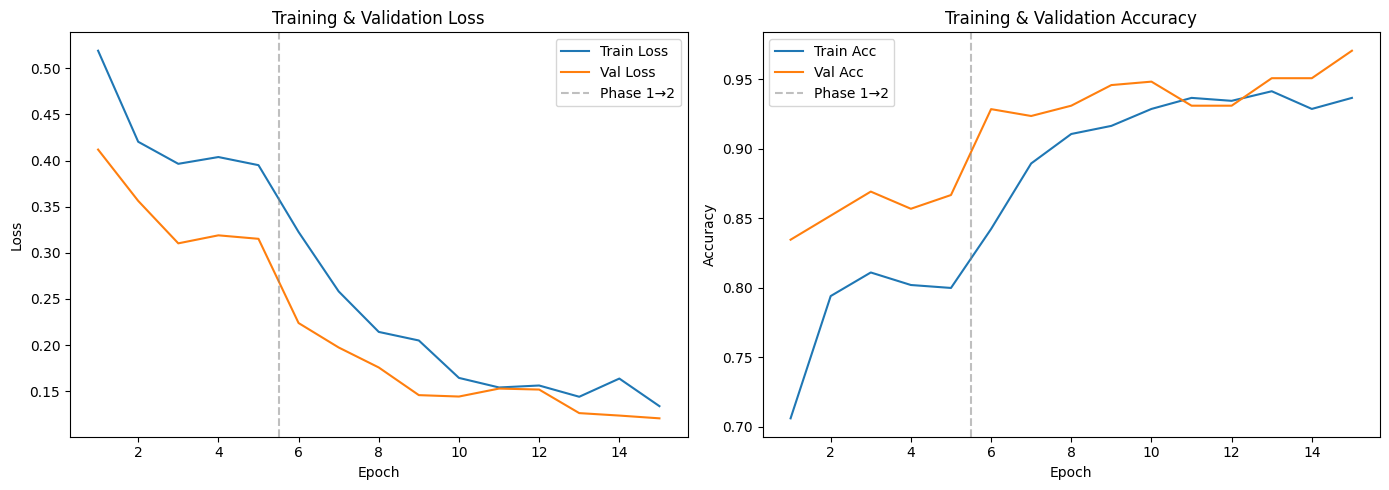

Saved to /content/drive/MyDrive/CS464_Wildfire/outputs/training_curves.png


In [19]:
# Training curves
epochs_range = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, history['train_loss'], label='Train Loss')
ax1.plot(epochs_range, history['val_loss'], label='Val Loss')
ax1.axvline(x=5.5, color='gray', linestyle='--', alpha=0.5, label='Phase 1→2')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training & Validation Loss')
ax1.legend()

ax2.plot(epochs_range, history['train_acc'], label='Train Acc')
ax2.plot(epochs_range, history['val_acc'], label='Val Acc')
ax2.axvline(x=5.5, color='gray', linestyle='--', alpha=0.5, label='Phase 1→2')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training & Validation Accuracy')
ax2.legend()

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150)
plt.show()
print(f'Saved to {OUTPUT_DIR}/training_curves.png')

## Cell Group 8: Evaluation

In [20]:
import json
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)

# Load best checkpoint
model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, 'best_efficientnet.pth'),
                                 map_location=device))
model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Testing'):
        images, labels = images.to(device), labels.to(device)
        with torch.amp.autocast('cuda'):
            outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        all_probs.extend(probs[:, 1].cpu().numpy())
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, pos_label=1)
rec = recall_score(all_labels, all_preds, pos_label=1)
f1 = f1_score(all_labels, all_preds, pos_label=1)
roc_auc = roc_auc_score(all_labels, all_probs)

print(f'Accuracy:  {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall:    {rec:.4f}')
print(f'F1-score:  {f1:.4f}')
print(f'ROC-AUC:   {roc_auc:.4f}')

Testing:   0%|          | 0/13 [00:00<?, ?it/s]

Accuracy:  0.9457
Precision: 0.9829
Recall:    0.9274
F1-score:  0.9544
ROC-AUC:   0.9896


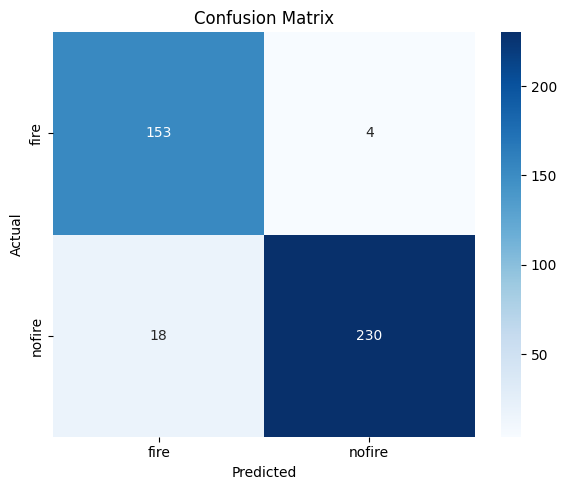

Saved to /content/drive/MyDrive/CS464_Wildfire/outputs/confusion_matrix.png


In [21]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()
print(f'Saved to {OUTPUT_DIR}/confusion_matrix.png')

In [22]:
# Save metrics to JSON
metrics = {
    'model': 'EfficientNet-B0 (fine-tuned)',
    'accuracy': round(acc, 4),
    'precision': round(prec, 4),
    'recall': round(rec, 4),
    'f1': round(f1, 4),
    'roc_auc': round(roc_auc, 4)
}
metrics_path = os.path.join(OUTPUT_DIR, 'metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)
print(f'Metrics saved to {metrics_path}')
print(json.dumps(metrics, indent=2))

Metrics saved to /content/drive/MyDrive/CS464_Wildfire/outputs/metrics.json
{
  "model": "EfficientNet-B0 (fine-tuned)",
  "accuracy": 0.9457,
  "precision": 0.9829,
  "recall": 0.9274,
  "f1": 0.9544,
  "roc_auc": 0.9896
}


## Cell Group 9: Summary

In [23]:
print('============ RESULTS ============')
print(f'Model: EfficientNet-B0 (fine-tuned)')
print(f'Accuracy:  {acc*100:.2f}%')
print(f'Precision: {prec*100:.2f}%')
print(f'Recall:    {rec*100:.2f}%')
print(f'F1-score:  {f1*100:.2f}%')
print(f'ROC-AUC:   {roc_auc:.4f}')
print('=================================')
print(f'Outputs saved to Google Drive:')
print(f'  - {OUTPUT_DIR}/class_distribution.png')
print(f'  - {OUTPUT_DIR}/training_curves.png')
print(f'  - {OUTPUT_DIR}/confusion_matrix.png')
print(f'  - {OUTPUT_DIR}/metrics.json')

============ RESULTS ============
Model: EfficientNet-B0 (fine-tuned)
Accuracy:  94.57%
Precision: 98.29%
Recall:    92.74%
F1-score:  95.44%
ROC-AUC:   0.9896
Outputs saved to Google Drive:
  - /content/drive/MyDrive/CS464_Wildfire/outputs/class_distribution.png
  - /content/drive/MyDrive/CS464_Wildfire/outputs/training_curves.png
  - /content/drive/MyDrive/CS464_Wildfire/outputs/confusion_matrix.png
  - /content/drive/MyDrive/CS464_Wildfire/outputs/metrics.json
